<div style="width: 100%; direction: rtl; text-align: left; margin: auto; font-family: Arial, sans-serif;">
    <br><br>
    <div style="width: 100%; margin: auto; background-color: transparent;">
        <table style="width: 100%; border-collapse: collapse;">
            <tr>
                <td style="width: 20%; text-align: right; border: none;">
                    <img src="https://noirlab.edu/public/media/archives/logos/screen/logo031.jpg" width="500" style="margin: 0;" alt="Logo Right">
                </td>
                <td style="width: 60%; text-align: left; border: none;">
                    <h1 style="color: #045F5F; font-size: 22px; margin: 0;">
                        <strong>Hydrogels Data Extraction</strong><br>
                    </h1>
                </td>
            </tr>
        </table>
    </div>
    <br>
    <p style="color: #045F5F; font-size: 20px;text-align: left; margin-top: 0px;">Mohammad Ali Safaei</p>
    <p style="font-size: 14px; color: #333; text-align: left; margin-top: 5px;">
        📧 Email: <a href="safaeimo@msu.edu" style="color: #045F5F;">safaeimo@msu.edu</a><br>
        🔗 <a href="https://www.linkedin.com/in/mohsafaei" target="_blank" style="color:#045F5F;"> LinkedIn</a>
    </p>

</div>


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import re
from wordcloud import WordCloud, STOPWORDS
from io import BytesIO
from PIL import Image

In [2]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["figure.autolayout"] = False
plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['ytick.major.width'] = 2
#plt. rcParams["legend.loc"] = 2   # or 9
colormap = LinearSegmentedColormap.from_list('custom',[(0,'#130DD3'),(0.5,'#3FDB82'),(1,'#EC3132')],N=256)
#colormap = LinearSegmentedColormap.from_list('custom',[(0,'#C1BEAB'),(1,'#2F6152')],N=256)  #,(0.5,'#08ad04'),(0.75,'#dee70e')

kwargs_lbl = dict([('fontsize',15)])#,('fontweight','bold')])
kwargs_axs = dict([('fontsize',12)])#,('fontweight','bold')])

In [3]:
def kw_count(txt,df):
    dif_count = 0
    idx = []
    for i,item in enumerate(df):
        if re.search(txt,item) != None:
            idx.append(i)
            dif_count += 1
    return idx

In [4]:
def matching_rows(df, column_name, pattern):
    df_matched = df[df[column_name].str.contains(pattern, regex=True, na=False)]
    arr = np.array(df_matched.index.tolist())
    return df_matched, arr

In [5]:
#df1 = pd.read_csv("SPA_2020.csv")
#df2 = pd.read_csv("Hydrogel_2019.csv")
df1 = pd.read_csv("SPA_2020.csv")
df2 = pd.read_csv("SPA_2021.csv")
df3 = pd.read_csv("SPA_2022.csv")
df4 = pd.read_csv("SPA_2023.csv")
df5 = pd.read_csv("SPA_2024.csv")
#df8 = pd.read_csv("Hydrogel_2025.csv")
df_tot = [df1,df2,df3,df4,df5]
df = pd.concat(df_tot,axis=0).reset_index(drop=True)

df['Abstract'].head()
#print(df["Abstract"].loc[26])

0    The transistor has revolutionized civilization...
1    Synthesis of artificial/natural polymeric biom...
2    Carbon-based piezoresistive nanomaterials are ...
3    In recent years, shape-memory polymers (SMPs) ...
4    Magnetoactive soft material (MASM) is distingu...
Name: Abstract, dtype: object

# Defining patterns

In [6]:
#pattern_peg = r"[Pp]oly.[eE]thylene.glycol|[Pp][Ee][Gg]"
pattern_DEA = r"[Dd]ielectric.[Ee]lastomer"
pattern_smp = r"[Ss]hape.[Mm]emory.[Pp]olymer"
pattern_hydrogel = r"[Hh]ydrogel"
pattern_IPMC = r"[Ii]onic.[Pp]olymer.[Mm]etal.[Cc]omposite|[Ii][Pp][Mm][Cc]"
#pattern_transport = r"[Tt]ransport"
#pattern_scaffold = r"[Ss]caffold"
#pattern_bioelec = r"[Ee]lectronic."
#pattern_robot = r"[Rr]obotic."

In [7]:
df_DEA,DEA_index = matching_rows(df,"Abstract",pattern_DEA) 
df_SMP,SMP_index = matching_rows(df,"Abstract",pattern_smp) 
df_hydrogel,hydrogel_index = matching_rows(df,"Abstract",pattern_hydrogel) 
df_IPMC,IPMC_index = matching_rows(df,"Abstract",pattern_IPMC) 
#df_transport,transport_index = matching_rows(df,"Abstract",pattern_transport) 


print("Number of articles in the literature in which the phrase '{}' is mentioned \033[1m{}\033[0m".format("Dielectric elastomer", len(DEA_index)))
print("Number of articles in the literature in which the phrase '{}' is mentioned \033[1m{}\033[0m".format("SMP", len(SMP_index)))
print("Number of articles in the literature in which the phrase '{}' is mentioned \033[1m{}\033[0m".format("Hydrogel", len(hydrogel_index)))
print("Number of articles in the literature in which the phrase '{}' is mentioned \033[1m{}\033[0m".format("IPMC", len(IPMC_index)))
#print("Number of articles in the literature in which the phrase '{}' is mentioned \033[1m{}\033[0m".format("Transport", len(transport_index)))



Number of articles in the literature in which the phrase 'Dielectric elastomer' is mentioned 785
Number of articles in the literature in which the phrase 'SMP' is mentioned 832
Number of articles in the literature in which the phrase 'Hydrogel' is mentioned 4681
Number of articles in the literature in which the phrase 'IPMC' is mentioned 218


In [8]:
arrs = [SMP_index,hydrogel_index]
intersected_list = DEA_index
for arr in arrs:  # Add more as needed
    intersected_list = np.intersect1d(intersected_list, arr)

print(intersected_list)
print(len(intersected_list))


[1480 4687]
2


In [9]:
df_most_related = df.loc[intersected_list]
print(len(df_most_related))
wanted_columns  = ['Author Keywords','Year','Title','Cited by','Abstract','DOI']
df_most_related.head()
df_most_related[wanted_columns].to_csv('Related_Literature.csv', index=True)  # `index=False` to skip saving the index

2


# "Drug Delivery" database

In [10]:
"""pattern_DDS = r"[Dd]rug.delivery\s"
df_DDS = df[df["Abstract"].str.contains(pattern_DDS, regex=True, na=False)]

print(len(df_DDS))
df_DDS.head()"""

'pattern_DDS = r"[Dd]rug.delivery\\s"\ndf_DDS = df[df["Abstract"].str.contains(pattern_DDS, regex=True, na=False)]\n\nprint(len(df_DDS))\ndf_DDS.head()'

In [11]:
tol_pandas = 2000

text1 = ' '.join(df['Index Keywords'][0:tol_pandas].astype(str).tolist())
text2 = ' '.join(df['Author Keywords'][0:tol_pandas].astype(str).tolist())
separator = ";"

text = separator.join([text1, text2])
#print(text)

In [12]:
text = re.sub(r'[^A-Za-z\s]', '', text)
text = text.lower()
stopwords = set(STOPWORDS)
stopwords.add("journal")
stopwords.add("priority")
stopwords.add("study")
stopwords.add("nan")
stopwords.add("polymer")
stopwords.add("material")

text = ' '.join(word for word in text.split() if word not in stopwords)
#print(text)
#print(type(text))
#print(len(text))

# WordCloud creation out of "Drug Delivery" database

C:\Users\moham\AppData\Local\Temp\ipykernel_9292\3305497354.py:29: UserWarning: The figure layout has changed to tight
  fig1.tight_layout()


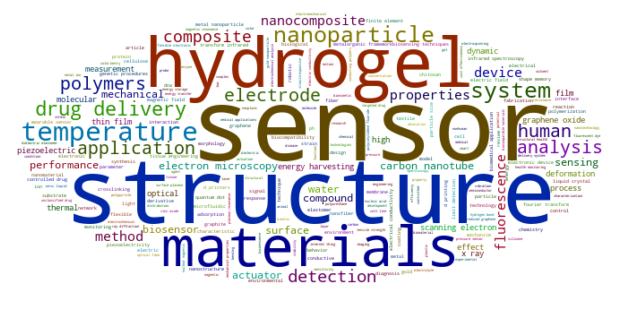

In [13]:
#wc = WordCloud(max_words=1000, mask=mask, stopwords=stopwords, margin=10,
def grey_color_func(word, font_size, position,orientation,random_state=None, **kwargs):
    hue = np.random.randint(0, 360)         # Full hue range for variety
    saturation = 100                         # Fully saturated
    lightness = np.random.randint(15, 35)    # Mid-range lightness for contrast
    return(f"hsl({hue}, {saturation}%, {lightness}%)")

with open('background.png', 'rb') as f:
    image_bytes = f.read()

mask_image = Image.open(BytesIO(image_bytes))
wc_mask = np.array(mask_image)

wordcloud = WordCloud(width=800, height=400,max_words=1000,background_color='white', margin=2, mask = wc_mask).generate(text)

wordcloud.recolor(color_func = grey_color_func)

fig1, ax1 = plt.subplots(num='Word Cloud',figsize = (7.0, 3.0)) 

#plt.figure(figsize=(8, 4))

# Save high-quality PDF (vector format)

ax1.imshow(wordcloud, interpolation='bilinear')
ax1.axis('off')  
#ax1.set_title("'Drug Delivery' word cloud ",**kwargs_lbl)
#fig1.savefig('DDS_WordColud.pdf',dpi=300)

fig1.tight_layout()
fig1.savefig(
    'DDS_WordCloud.pdf',  # corrected typo in filename
    dpi=600,              # higher DPI for crisp images
    bbox_inches='tight',  # trims excess whitespace
    pad_inches=0.1,       # small border
    transparent=True      # optional, for clean backgrounds
)

plt.show()



# "Drug Delivery" count in the literature

In [14]:
subdatasets = {year: group for year, group in df.groupby('Year')}

In [15]:
print(subdatasets[2020].shape)
#subdata_2018 = subdatasets[2018]['Abstract']
#subdata_2019 = subdatasets[2019]['Abstract']
subdata_2020 = subdatasets[2020]['Abstract']
subdata_2021 = subdatasets[2021]['Abstract']
subdata_2022 = subdatasets[2022]['Abstract']
subdata_2023 = subdatasets[2023]['Abstract']
subdata_2024 = subdatasets[2024]['Abstract']
#subdata_2025 = subdatasets[2025]['Abstract']

(7474, 8)


In [16]:
#DDS_idx_2018 = kw_count(pattern_DDS,subdata_2018)
#DDS_idx_2019 = kw_count(pattern_DDS,subdata_2019)
DEA_idx_2020 = kw_count(pattern_DEA,subdata_2020)
DEA_idx_2021 = kw_count(pattern_DEA,subdata_2021)
DEA_idx_2022 = kw_count(pattern_DEA,subdata_2022)
DEA_idx_2023 = kw_count(pattern_DEA,subdata_2023)
DEA_idx_2024 = kw_count(pattern_DEA,subdata_2024)
#DDS_idx_2025 = kw_count(pattern_DDS,subdata_2025)

DEA_rpt = np.array([len(DEA_idx_2020), len(DEA_idx_2021), len(DEA_idx_2022), len(DEA_idx_2023), 
                    len(DEA_idx_2024)])#DDS_rpt = DDS_rpt.to_numpy()

In [17]:
#SMP_idx_2018 = kw_count(pattern_smp,subdata_2018)
#SMP_idx_2019 = kw_count(pattern_smp,subdata_2019)
SMP_idx_2020 = kw_count(pattern_smp,subdata_2020)
SMP_idx_2021 = kw_count(pattern_smp,subdata_2021)
SMP_idx_2022 = kw_count(pattern_smp,subdata_2022)
SMP_idx_2023 = kw_count(pattern_smp,subdata_2023)
SMP_idx_2024 = kw_count(pattern_smp,subdata_2024)


SMP_rpt = np.array([len(SMP_idx_2020), len(SMP_idx_2021), len(SMP_idx_2022), len(SMP_idx_2023), 
                    len(SMP_idx_2024)])#DDS_rpt = DDS_rpt.to_numpy()


hyd_idx_2020 = kw_count(pattern_hydrogel,subdata_2020)
hyd_idx_2021 = kw_count(pattern_hydrogel,subdata_2021)
hyd_idx_2022 = kw_count(pattern_hydrogel,subdata_2022)
hyd_idx_2023 = kw_count(pattern_hydrogel,subdata_2023)
hyd_idx_2024 = kw_count(pattern_hydrogel,subdata_2024)


hyd_rpt = np.array([len(hyd_idx_2020), len(hyd_idx_2021), len(hyd_idx_2022), len(hyd_idx_2023), 
                    len(hyd_idx_2024)])#DDS_rpt = DDS_rpt.to_numpy()



In [18]:
#belec_idx_2018 = kw_count(pattern_robot,subdata_2018)
#belec_idx_2019 = kw_count(pattern_robot,subdata_2019)
IPMC_idx_2020 = kw_count(pattern_IPMC,subdata_2020)
IPMC_idx_2021 = kw_count(pattern_IPMC,subdata_2021)
IPMC_idx_2022 = kw_count(pattern_IPMC,subdata_2022)
IPMC_idx_2023 = kw_count(pattern_IPMC,subdata_2023)
IPMC_idx_2024 = kw_count(pattern_IPMC,subdata_2024)
#belec_idx_2025 = kw_count(pattern_robot,subdata_2025)

IPMC_rpt = np.array([len(IPMC_idx_2020), len(IPMC_idx_2021), len(IPMC_idx_2022), len(IPMC_idx_2023), 
                    len(IPMC_idx_2024)])#DDS_rpt = DDS_rpt.to_numpy()"""

In [19]:
"""print('Number of DDS 2018 repetition: ',len(DDS_idx_2018))
print('Number of DDS 2019 repetition: ',len(DDS_idx_2019))
print('Number of DDS 2020 repetition: ',len(DDS_idx_2020))
print('Number of DDS 2021 repetition: ',len(DDS_idx_2021))
print('Number of DDS 2022 repetition: ',len(DDS_idx_2022))
print('Number of DDS 2023 repetition: ',len(DDS_idx_2023))
print('Number of DDS 2024 repetition: ',len(DDS_idx_2024))
print('Number of DDS 2025 repetition: ',len(DDS_idx_2025))"""

"print('Number of DDS 2018 repetition: ',len(DDS_idx_2018))\nprint('Number of DDS 2019 repetition: ',len(DDS_idx_2019))\nprint('Number of DDS 2020 repetition: ',len(DDS_idx_2020))\nprint('Number of DDS 2021 repetition: ',len(DDS_idx_2021))\nprint('Number of DDS 2022 repetition: ',len(DDS_idx_2022))\nprint('Number of DDS 2023 repetition: ',len(DDS_idx_2023))\nprint('Number of DDS 2024 repetition: ',len(DDS_idx_2024))\nprint('Number of DDS 2025 repetition: ',len(DDS_idx_2025))"

C:\Users\moham\AppData\Local\Temp\ipykernel_9292\2545152283.py:48: UserWarning: The figure layout has changed to tight
  fig2.tight_layout()


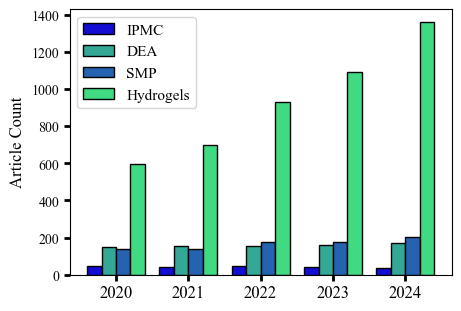

In [20]:

scaled_cm = (DEA_rpt - DEA_rpt.min()) / (DEA_rpt.max() - DEA_rpt.min())
cmap = colormap(scaled_cm)


categs = ['2020', '2021','2022','2023','2024']

fig2, ax2 = plt.subplots(num='DDS in literature',figsize=(4.5, 3.0)) 

bar = np.arange(len(categs))
bar_width = 0.2  # We make the bars a bit narrower to fit four



#ax2.tick_params(axis='x',          # changes apply to the x-axis
#    which='both',           # both major and minor ticks are affected
#    bottom=False,           # ticks along the bottom edge are off
#    top=False,              # ticks along the top edge are off
#    labelbottom=True)       # labels along the bottom edge are off
#ticksy = np.linspace(0, 5000, 6)
#ax2.set_yticks(ticksy,**kwargs_axs)
#ax2.set_ylabel('Number of repetition',**kwargs_lbl) 
#ax2.set_xticklabels(categs,**kwargs_axs)
#ax2.set_ylim([0,5000])
#ax2.set_xlim([1-tol,17+tol])
#ax2.set_title('Keywords in Literature',**kwargs_lbl)

ax2.set_ylabel('Article Count', fontsize=12)
#ax2.set_title('Keywords in Literature', fontsize=16, fontweight='bold')
ax2.set_xticks(bar)
ax2.set_xticklabels(categs, fontsize=12)

ax2.bar(bar - 1.5 * bar_width, IPMC_rpt,bar_width,color = cmap[0],
        edgecolor ='black',label ='IPMC')
ax2.bar(bar - 0.5 * bar_width, DEA_rpt,bar_width,color = cmap[1],
        edgecolor ='black',label ='DEA')
ax2.bar(bar + 0.5 * bar_width, SMP_rpt,bar_width,color = cmap[2],
        edgecolor ='black',label ='SMP')
ax2.bar(bar + 1.5 * bar_width, hyd_rpt,bar_width,color = cmap[3], 
        edgecolor ='black',label ='Hydrogels')     

ax2.legend(fontsize=11)

#ax2.bar(bar[4], DDS_rpt[4],color = cmap[4],edgecolor ='black',label ='2022')     
#ax2.bar(bar[5], DDS_rpt[5],color = cmap[5],edgecolor ='black',label ='2023')     
#ax2.bar(bar[6], DDS_rpt[6],color = cmap[6],edgecolor ='black',label ='2024')    
#ax2.bar(bar[7], DDS_rpt[7],color = cmap[7],edgecolor ='black',label ='2025')    

fig2.tight_layout()
fig2.savefig('Keyword_Literature.pdf',dpi=600)
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\moham\AppData\Local\Temp\ipykernel_9292\2654790091.py:50: UserWarning: The figure layout has changed to tight
  fig3.tight_layout()


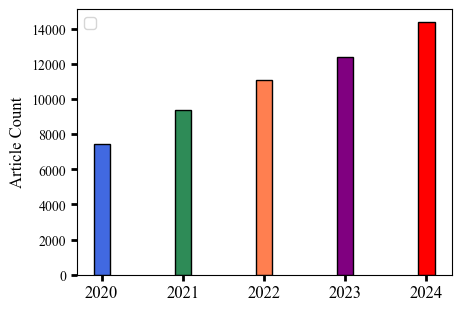

In [21]:
#scaled_cm = (DEA_rpt - DEA_rpt.min()) / (DEA_rpt.max() - DEA_rpt.min())
#cmap = colormap(scaled_cm)


categs = ['2020', '2021','2022','2023','2024']
SMA_lit = [7474,9411,11069,12389,14404]  ## 2025: 9842
fig3, ax3 = plt.subplots(num='DDS in literature',figsize=(4.5, 3.0)) 

bar = np.arange(len(categs))
bar_width = 0.2  # We make the bars a bit narrower to fit four



#ax2.tick_params(axis='x',          # changes apply to the x-axis
#    which='both',           # both major and minor ticks are affected
#    bottom=False,           # ticks along the bottom edge are off
#    top=False,              # ticks along the top edge are off
#    labelbottom=True)       # labels along the bottom edge are off
#ticksy = np.linspace(0, 5000, 6)
#ax2.set_yticks(ticksy,**kwargs_axs)
#ax2.set_ylabel('Number of repetition',**kwargs_lbl) 
#ax2.set_xticklabels(categs,**kwargs_axs)
#ax2.set_ylim([0,5000])
#ax2.set_xlim([1-tol,17+tol])
#ax2.set_title('Keywords in Literature',**kwargs_lbl)

ax3.set_ylabel('Article Count', fontsize=12)
#ax3.set_title('"Smart Polymer Actuators" in Literature', fontsize=16, fontweight='bold')
ax3.set_xticks(bar)
ax3.set_xticklabels(categs, fontsize=12)

ax3.bar(0, SMA_lit[0],bar_width,color='royalblue',
        edgecolor ='black')
ax3.bar(1, SMA_lit[1],bar_width,color='seagreen',
        edgecolor ='black')
ax3.bar(2, SMA_lit[2],bar_width,color='coral',
        edgecolor ='black')
ax3.bar(3, SMA_lit[3],bar_width,color='purple', 
        edgecolor ='black')     
ax3.bar(4, SMA_lit[4],bar_width,color='red', 
        edgecolor ='black')  

ax3.legend(fontsize=11)

#ax2.bar(bar[4], DDS_rpt[4],color = cmap[4],edgecolor ='black',label ='2022')     
#ax2.bar(bar[5], DDS_rpt[5],color = cmap[5],edgecolor ='black',label ='2023')     
#ax2.bar(bar[6], DDS_rpt[6],color = cmap[6],edgecolor ='black',label ='2024')    
#ax2.bar(bar[7], DDS_rpt[7],color = cmap[7],edgecolor ='black',label ='2025')    

fig3.tight_layout()
fig3.savefig('SPA_in_Literature.pdf',dpi=600)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Your Data (with the 4th product)
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a_sales = [25, 30, 35, 50]
product_b_sales = [40, 32, 28, 55]
product_c_sales = [15, 45, 38, 60]
product_d_sales = [30, 25, 42, 48] # New product data

# 2. Set Up Bar Positions (The Core Logic for 4 Bars)
# This creates the base positions for the groups on the x-axis (e.g., 0, 1, 2, 3)
x = np.arange(len(categories))  
bar_width = 0.2  # We make the bars a bit narrower to fit four

# Create the figure and axes object
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Create the Bars for each of the four products
# We calculate new offsets to center the group of four bars around the tick.
rects1 = ax.bar(x - 1.5 * bar_width, product_a_sales, bar_width, label='Product A', color='royalblue')
rects2 = ax.bar(x - 0.5 * bar_width, product_b_sales, bar_width, label='Product B', color='seagreen')
rects3 = ax.bar(x + 0.5 * bar_width, product_c_sales, bar_width, label='Product C', color='coral')
rects4 = ax.bar(x + 1.5 * bar_width, product_d_sales, bar_width, label='Product D', color='purple') # New bar

# 4. Add Labels, Title, and Ticks
ax.set_ylabel('Sales (in thousands)', fontsize=12)
ax.set_title('Quarterly Sales Performance by Product', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=11)

# Add a light grid for better readability
# Adjust layout to prevent labels from overlapping
fig.tight_layout()

# 5. Display the Plot
plt.show()


In [19]:
print(df['Abstract'].iloc[intersected_list[0]])

Drug delivery to the brain is challenging due to a highly regulated blood-brain barrier (BBB) and a complex brain microenvironment. Nanoparticles, due to their tailorability, provide promising platforms to enhance therapeutic delivery and achieve controlled release and disease-specific localization in the brain. However, we have yet to fully understand the complex interactions between nanoparticles and the biological environments in which they operate. It is important to perform a systematic study to characterize nanoparticle behavior as a function of ion composition, concentration, and pH in cerebrospinal fluid (CSF). These could alter nanoparticle biological identity and influence diffusive capability and cellular uptake. In this study, poly(ethylene glycol) (PEG)-coated and carboxyl-coated polystyrene (PS-PEG and PS-COOH respectively) nanoparticles (NPs) were used to evaluate the aggregation kinetics, colloidal stability, and diffusive capability of nanoparticles in conditions relev

In [20]:
print(df['Abstract'].iloc[intersected_list[1]])

A sustained drug delivery system is developed by using nonionic polymer to formulate drug release rate from silica based capsules. To serve this purpose, silica based capsules filled with poly(ethylene glycol) (PEG) were incorporated with a veterinary antibiotic drug enrofloxacin (EFX); as a model hydrophobic drug by using a general and facile sol-gel route. The physicochemical properties of the prepared drug-loaded composites were investigated by scanning electron microscope (SEM), nitrogen adsorption, Fourier transform infrared spectroscopy and thermal analysis (TGA). The impact of the media's ionic strength on the drug release was evaluated over a range of 0–0.4 M to simulate the gastrointestinal feed in two physiological pH conditions. Sodium chloride was applied for ionic concentration adjustment due to its ability to salt out polymers in the midrange of the lyotropic series. Simultaneously, the drug release kinetics was evaluated by fitting experimental data to common empirical (

In [24]:
from sentence_transformers import SentenceTransformer, util


In [29]:
!pip install huggingface_hub[hf_xet]

# Load lightweight semantic model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')    ## msmarco-distilbert-base-tas-b	##

# Your prompt (what you want to check relevance against)
prompt = "Check whether this content is relevant to drug release in polyethylene glycol (PEG) hydrogels. Specifically, drug diffusion through PEG networks is being considered."

# Encode the prompt once
prompt_embedding = model.encode(prompt, convert_to_tensor=True)

# Your list of 5000+ texts
texts = [df['Abstract'].iloc[intersected_list[-2]]]
print(len(texts))

# Store relevant texts and their indices
relevant_texts = []
relevant_indices = []

# Threshold for relevance (0.4–0.8 is common; adjust as needed)
threshold = 0.5

#similarity = util.cos_sim(prompt_embedding, text_embedding).item()
#print(similarity)
#print(textt)

for i, text in enumerate(texts):
    text_embedding = model.encode(text, convert_to_tensor=True)
    similarity = util.cos_sim(prompt_embedding, text_embedding).item()
    print(similarity)
    
    if similarity >= threshold:
        relevant_texts.append(text)
        relevant_indices.append(i)

# Output
print(f"{len(relevant_texts)} relevant texts found.")
print("Indices of relevant texts:", relevant_indices)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  45%|####4     | 73.4M/164M [00:00<?, ?B/s]

C:\Users\moham\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


1
0.46847671270370483
0 relevant texts found.
Indices of relevant texts: []


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Choose model
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # or "distilgpt2"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
#model = AutoModel.from_pretrained("model/path", local_files_only=True)

# Create a text generation pipeline
generator = pipeline(df['Abstract'].iloc[intersected_list[-2]], model=model, tokenizer=tokenizer)

# Generate text
#prompt = "Check whether this content is relevant to drug release in polyethylene glycol (PEG) hydrogels. Specifically, drug diffusion through PEG networks is being considered."

prompt = """In this paper, we report on the drug release behavior of poly(ethylene glycol) (PEG) hydrogels. 
    The primary mechanism governing drug release and transport within these hydrogels is passive diffusion. Our experimental results provide valuable insights into the kinetics and efficiency of drug release from PEG-based hydrogels. 
    These findings contribute to a better understanding of the underlying processes and can inform the design and optimization of advanced drug delivery systems. 
    Ultimately, this research has the potential to enhance the quality, efficacy, and safety of future drug delivery technologies."""



result = generator(prompt, max_length=50, do_sample=True)
print(result[0]['generated_text'])

In [ ]:
prompt = """In this paper, we report on the drug release behavior of poly(ethylene glycol) (PEG) hydrogels. 
    The primary mechanism governing drug release and transport within these hydrogels is passive diffusion. Our experimental results provide valuable insights into the kinetics and efficiency of drug release from PEG-based hydrogels. 
    These findings contribute to a better understanding of the underlying processes and can inform the design and optimization of advanced drug delivery systems. 
    Ultimately, this research has the potential to enhance the quality, efficacy, and safety of future drug delivery technologies."""

